In [1]:
from google.colab import files
uploaded = files.upload() #내드라이브에 csv파일 불러오기

Saving shipping.csv to shipping.csv


# **제품 배송 시간에 맟춰 배송되나요? 전자상거래 고객의 요구에 부응하기위해**

In [ ]:
pip install -U pandas-profiling #pandas-profiling 설치

In [3]:
pip install MarkupSafe==2.0.1

  Attempting uninstall: MarkupSafe
    Found existing installation: MarkupSafe 2.1.1
    Uninstalling MarkupSafe-2.1.1:
      Successfully uninstalled MarkupSafe-2.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires markupsafe~=2.1.1, but you have markupsafe 2.0.1 which is incompatible.
datascience 0.10.6 requires folium==0.2.1, but you have folium 0.8.3 which is incompatible.


In [97]:
#https://www.kaggle.com/datasets/prachi13/customer-analytics 해당 케글 사이트
import io
import pandas as pd
df = pd.read_csv(io.BytesIO(uploaded['shipping.csv'])) #data.csv불러오기
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [5]:
from pandas_profiling import ProfileReport
pr=df.profile_report() 
pr.to_file('./pr_report.html') #pr_report.html 파일로저장

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [6]:
df.shape # 행 10999 열 12개

(10999, 12)

**콘텐츠**
모델 구축에 사용된 데이터 세트에는 12개의 변수에 대한 10999개의 관찰이 포함되었습니다.
데이터에는 다음 정보가 포함됩니다.

**ID**: 고객의 ID 번호입니다.   
**창고** 블록: 회사는 A,B,C,D,E와 같은 블록으로 구분된 큰 창고를 가지고 있습니다.   
**배송방법**: 회사는 선박, 항공, 육로 등 다양한 방법으로 제품을 배송합니다.   
**고객상담전화** : 배송조회 문의에서 걸려온 전화수입니다.   
**고객 평가**: 회사는 모든 고객으로부터 평가했습니다. 1이 가장 낮음(최악), 5가 가장 높음(최상)입니다.   
**제품 비용** : 제품 비용(미국 달러).   
**이전 구매**: 이전 구매 수.   
**제품 중요도**: 회사는 제품을 낮음, 중간, 높음과 같은 다양한 매개변수로 분류했습니다.   
**성별**: 남성과 여성.   
**할인 제공**: 특정 제품에 대해 제공되는 할인.   
**무게(g)**: 무게(g)입니다.   
**정시 도달**: 목표 변수로, 1은 제품이 정시에 도달하지 않았음을 나타내고 0은 정시에 도달했음을 나타냅니다.

In [7]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   10999 non-null  int64 
 1   Warehouse_block      10999 non-null  object
 2   Mode_of_Shipment     10999 non-null  object
 3   Customer_care_calls  10999 non-null  int64 
 4   Customer_rating      10999 non-null  int64 
 5   Cost_of_the_Product  10999 non-null  int64 
 6   Prior_purchases      10999 non-null  int64 
 7   Product_importance   10999 non-null  object
 8   Gender               10999 non-null  object
 9   Discount_offered     10999 non-null  int64 
 10  Weight_in_gms        10999 non-null  int64 
 11  Reached.on.Time_Y.N  10999 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 1.0+ MB


In [9]:
df.isnull().sum() # 결측치 제로! Good!

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

In [79]:
df.shape

(10999, 12)

In [10]:
round(df[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product','Prior_purchases', 'Product_importance',
                'Discount_offered', 'Weight_in_gms','Reached.on.Time_Y.N']].corr(),2)

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Customer_care_calls,1.00,0.01,0.32,0.18,-0.13,-0.28,-0.07
Customer_rating,0.01,1.00,0.01,0.01,-0.00,-0.00,0.01
Cost_of_the_Product,0.32,0.01,1.00,0.12,-0.14,-0.13,-0.07
Prior_purchases,0.18,0.01,0.12,1.00,-0.08,-0.17,-0.06
Discount_offered,-0.13,-0.00,-0.14,-0.08,1.00,-0.38,0.40
Weight_in_gms,-0.28,-0.00,-0.13,-0.17,-0.38,1.00,-0.27
Reached.on.Time_Y.N,-0.07,0.01,-0.07,-0.06,0.40,-0.27,1.00


In [100]:
df.duplicated(subset = ['ID']).sum() # 중복된 ID 없는거 확인!

0

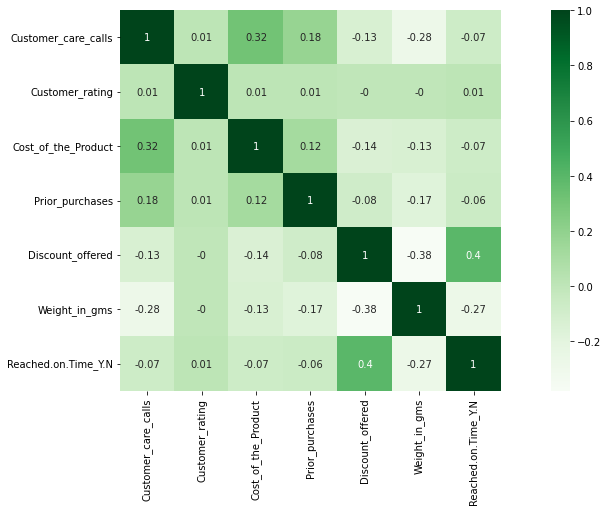

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize = (18, 7))
sns.heatmap(round(df[['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product','Prior_purchases', 'Product_importance',
                'Discount_offered', 'Weight_in_gms','Reached.on.Time_Y.N']].corr(),2),square = True, cmap = 'Greens', annot = True);
plt.show()

상관계수로 봤을때   
Reached.on.Time_YN는 Weight_in_gm와 Discount_offered  
Customer_care_calls는 Cost_of_the_Product와 Weight_in_gms   
Discount_offered는 Weight_in_gms 밀접한 관계가 있을것으로 보입니다.

In [12]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [13]:
df.rename(columns = {'Reached.on.Time_Y.N' : 'Reached_on_Time_YN'}, inplace = True) #편의를 위해 열이름 변경!

In [14]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [16]:
df.Warehouse_block.value_counts() #F=3666은 아마 E =  1833 결측된듯하다. 모든 블락의 count가 같기때문에 분석에 무의미하다.

F    3666
D    1834
A    1833
B    1833
C    1833
Name: Warehouse_block, dtype: int64

In [17]:
df.Mode_of_Shipment.value_counts()

Ship      7462
Flight    1777
Road      1760
Name: Mode_of_Shipment, dtype: int64

In [78]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [105]:
df.columns

Index(['ID', 'Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

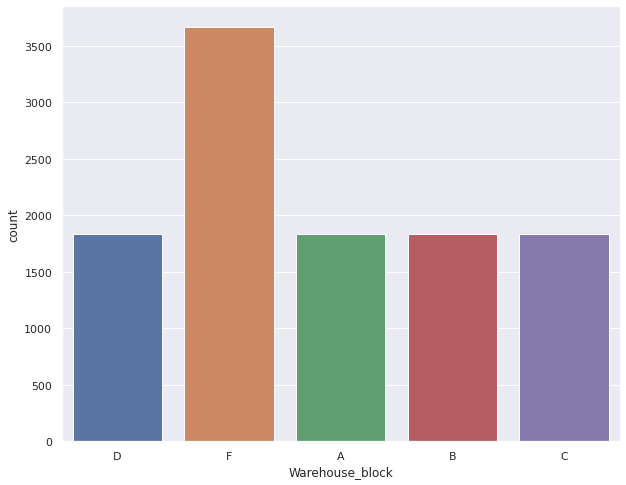

In [120]:
import seaborn as sns

sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,1]);

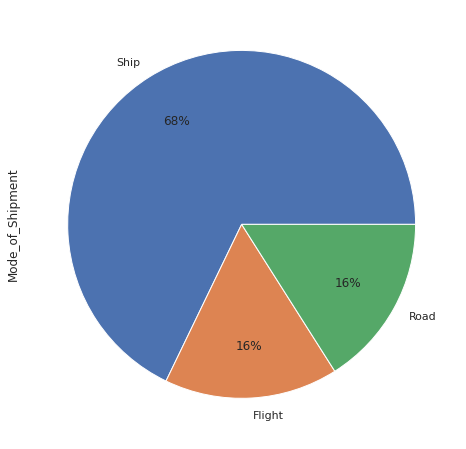

In [18]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Mode_of_Shipment.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

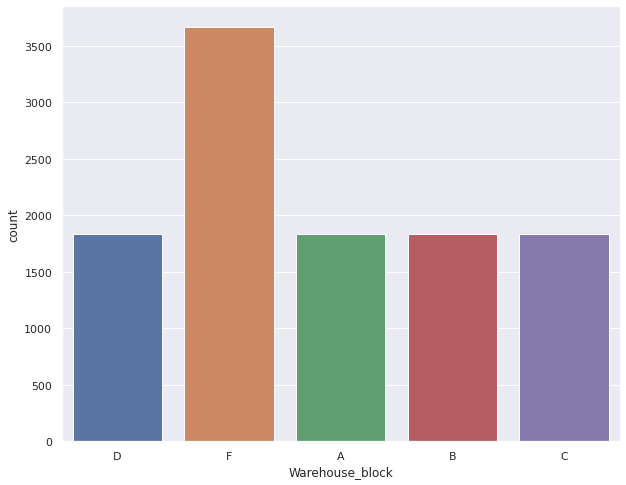

In [122]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,1]);

In [22]:
df.Customer_care_calls.value_counts()

4    3557
3    3217
5    2328
6    1013
2     638
7     246
Name: Customer_care_calls, dtype: int64

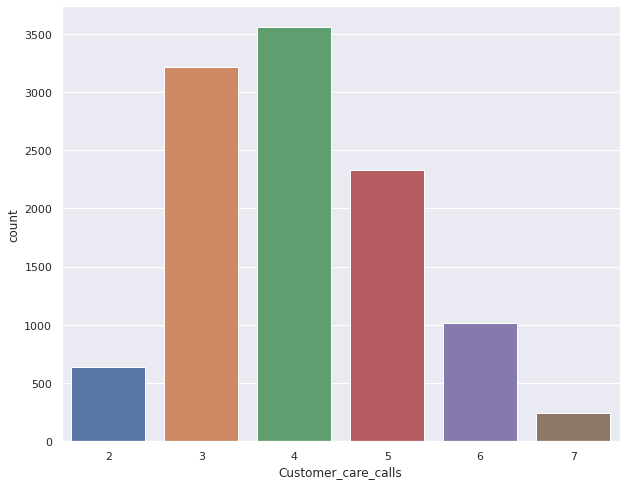

In [123]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,3]);

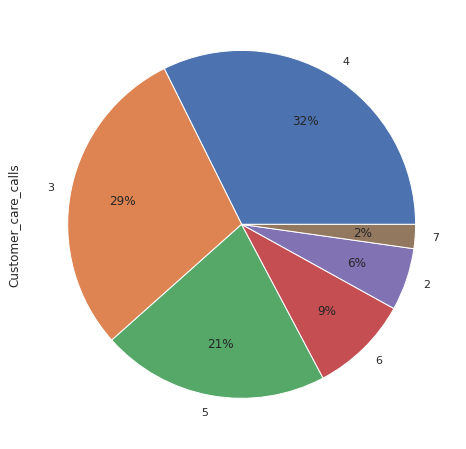

In [65]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Customer_care_calls.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [24]:
df[df['Reached_on_Time_YN'] ==1]['Customer_care_calls'].value_counts()

4    2126
3    2011
5    1360
6     523
2     416
7     127
Name: Customer_care_calls, dtype: int64

In [25]:
Carecall_Y = df[df['Reached_on_Time_YN'] ==1]['Customer_care_calls'].value_counts()
Carecall_N = df[df['Reached_on_Time_YN'] ==0]['Customer_care_calls'].value_counts()

In [26]:
df_carecall = pd.DataFrame([Carecall_Y, Carecall_N])
df_carecall = df_carecall.reset_index()
df_carecall = df_carecall.drop(['index'], axis = 1)

In [27]:
df_carecall.index = ['no arrived', 'arrived']
df_carecall

,4,3,5,6,2,7
no arrived,2126,2011,1360,523,416,127
arrived,1431,1206,968,490,222,119


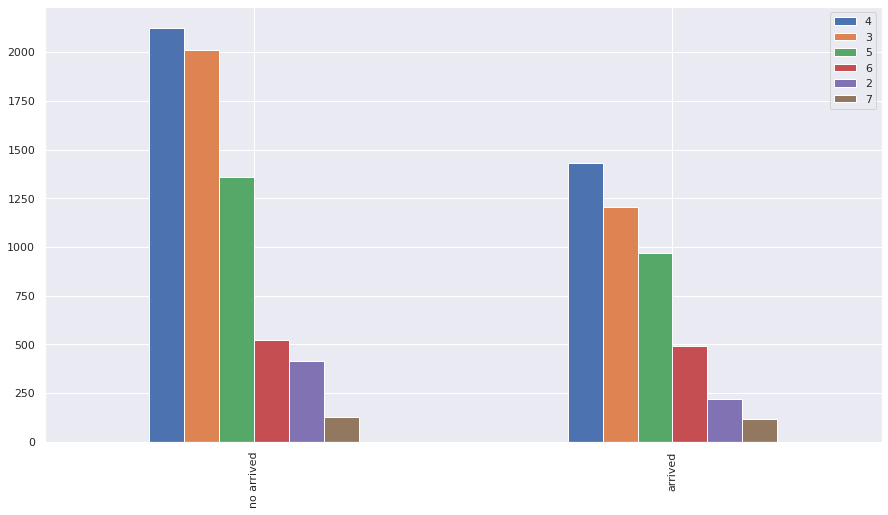

In [28]:
df_carecall.plot(kind = 'bar');

In [29]:
df.Customer_rating.value_counts()

3    2239
1    2235
4    2189
5    2171
2    2165
Name: Customer_rating, dtype: int64

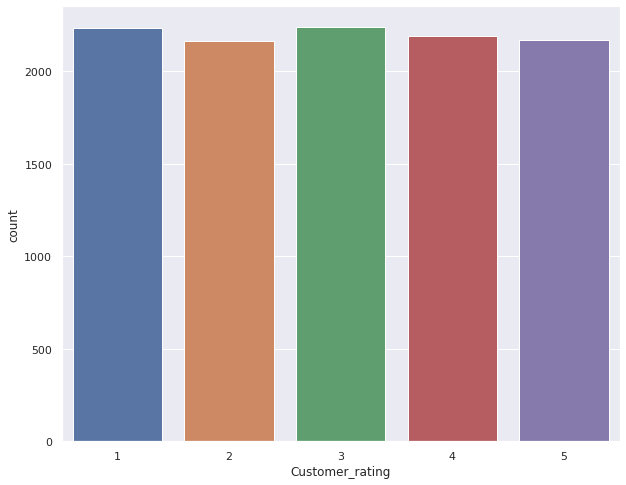

In [125]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,4]);

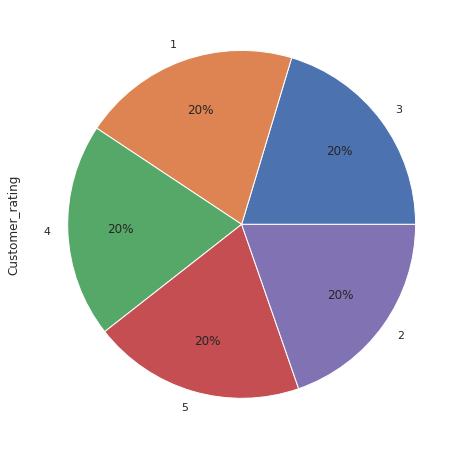

In [30]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Customer_rating.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [31]:
df.Prior_purchases.value_counts()

3     3955
2     2599
4     2155
5     1287
6      561
10     178
7      136
8      128
Name: Prior_purchases, dtype: int64

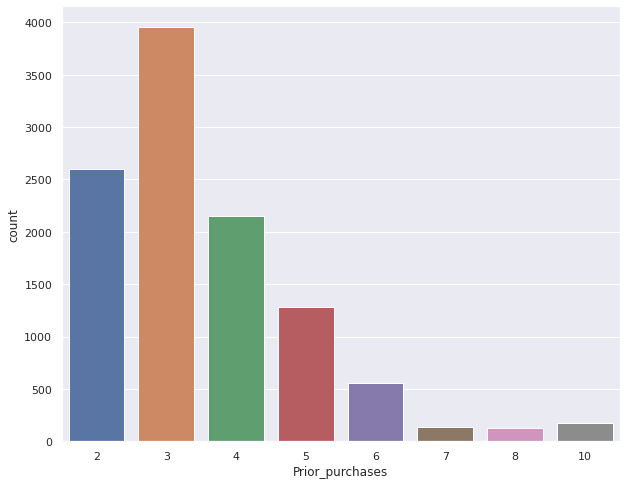

In [135]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,6]);

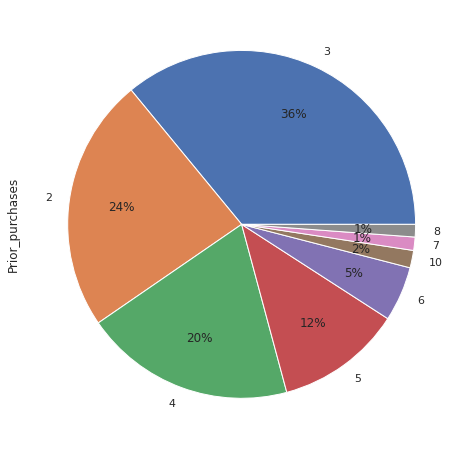

In [32]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Prior_purchases.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [33]:
df.Product_importance.value_counts()

low       5297
medium    4754
high       948
Name: Product_importance, dtype: int64

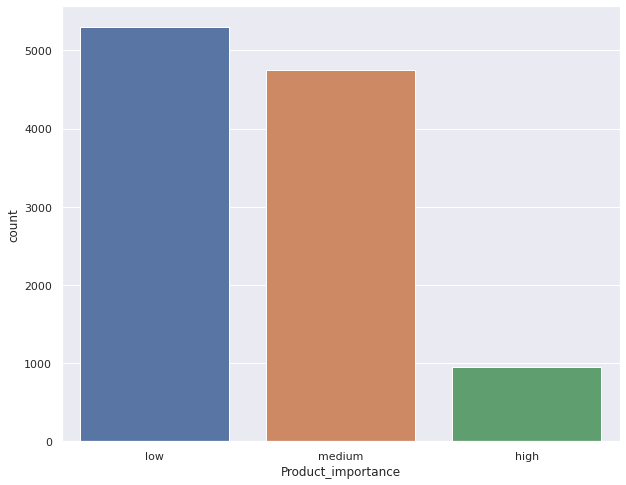

In [128]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,7]);

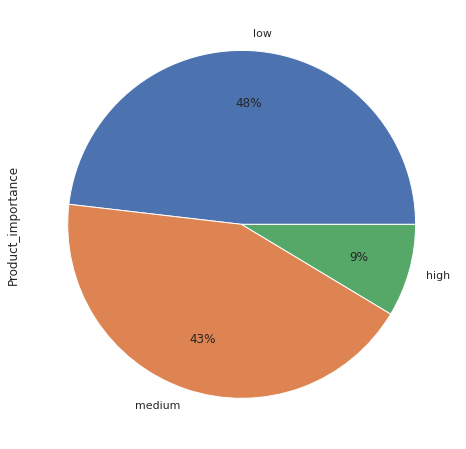

In [34]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Product_importance.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [35]:
df.Gender.value_counts()

F    5545
M    5454
Name: Gender, dtype: int64

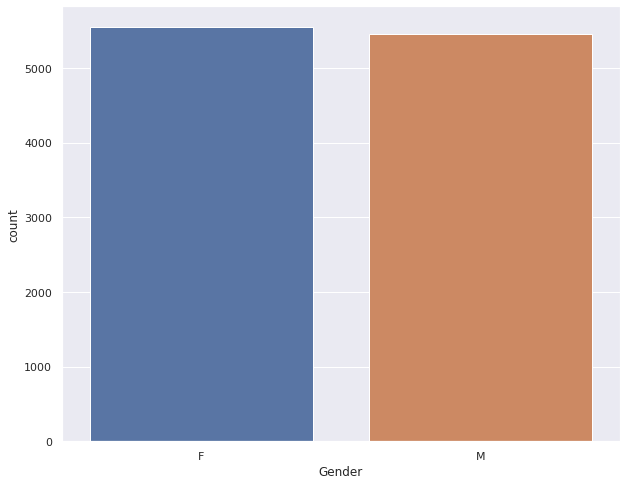

In [129]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,8]);

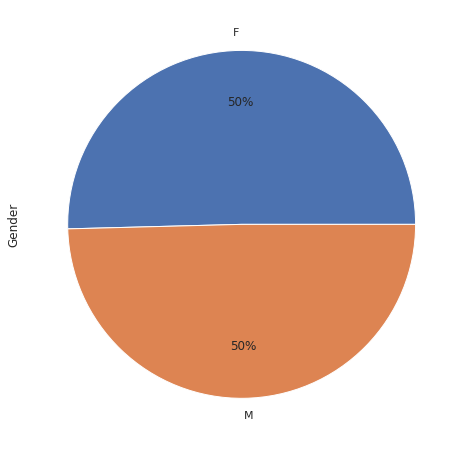

In [36]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Gender.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [37]:
df.Reached_on_Time_YN.value_counts()

1    6563
0    4436
Name: Reached_on_Time_YN, dtype: int64

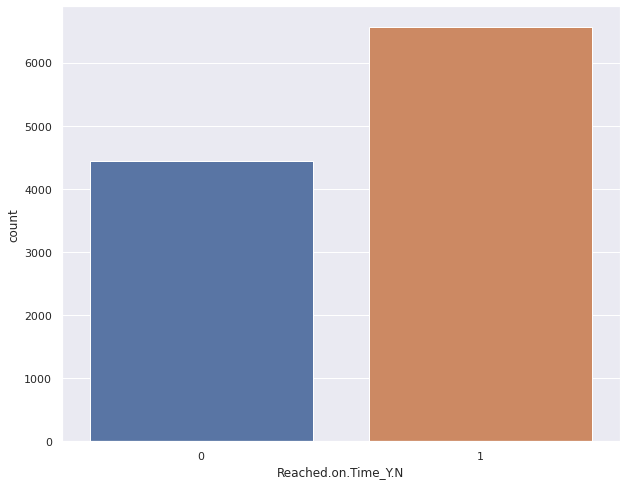

In [134]:
sns.set(rc={'figure.figsize':(10,8)})
sns.countplot(x = df.iloc[:,11]);

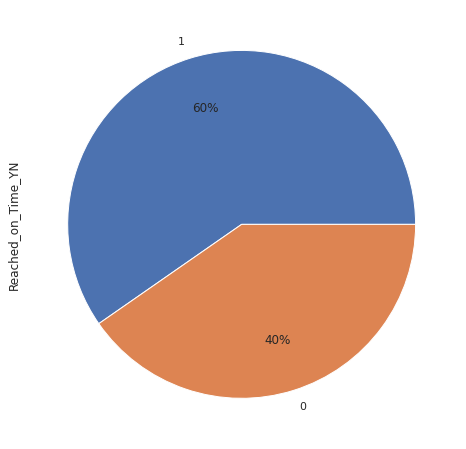

In [38]:
sns.set(rc={'figure.figsize':(15,8)})
wedgeprops = {'width': 0.6, 'linewidth': 1, 'edgecolor': 'black'}
df.Reached_on_Time_YN.value_counts().plot(kind = 'pie', autopct = '%1.0f%%', 
                                        pctdistance=0.7);

In [39]:
df_shipment = df.groupby(['Mode_of_Shipment','Reached_on_Time_YN'])[['Reached_on_Time_YN']].count()
df_shipment.rename(columns = {'Reached_on_Time_YN' : 'Reached_on_Time_Count'}, inplace = True)
df_shipment = df_shipment.reset_index()

In [40]:
Shipment_Y = df[df['Reached_on_Time_YN'] ==1]['Mode_of_Shipment'].value_counts()
Shipment_N = df[df['Reached_on_Time_YN'] ==0]['Mode_of_Shipment'].value_counts()

In [41]:
df_shipment = pd.DataFrame([Shipment_Y, Shipment_N])
df_shipment = df_shipment.reset_index()
df_shipment = df_shipment.drop(['index'], axis = 1)

In [42]:
df_shipment.index = ['no arrived', 'arrived']
df_shipment

,Ship,Flight,Road
no arrived,4459,1069,1035
arrived,3003,708,725


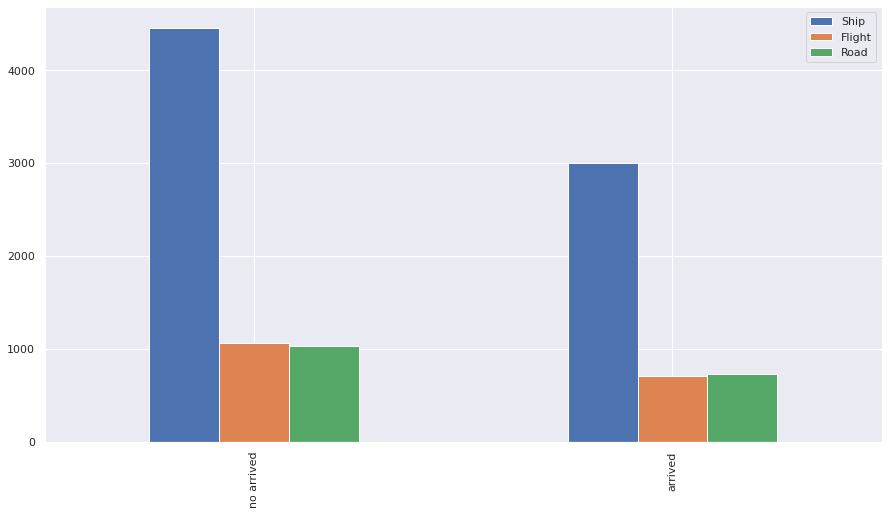

In [75]:
df_shipment.plot(kind = 'bar');

In [44]:
df.head(3)

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached_on_Time_YN
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [45]:
Shipment_YN = df[['Mode_of_Shipment', 'Reached_on_Time_YN']].astype('category')
Shipment_YN

,Mode_of_Shipment,Reached_on_Time_YN
0,Flight,1
1,Flight,1
2,Flight,1
3,Flight,1
4,Flight,1
...,...,...
10994,Ship,1
10995,Ship,0
10996,Ship,0
10997,Ship,0


In [46]:
Discount_Y = df[df['Reached_on_Time_YN'] ==1]['Discount_offered'].value_counts()
Discount_N = df[df['Reached_on_Time_YN'] ==0]['Discount_offered'].value_counts()

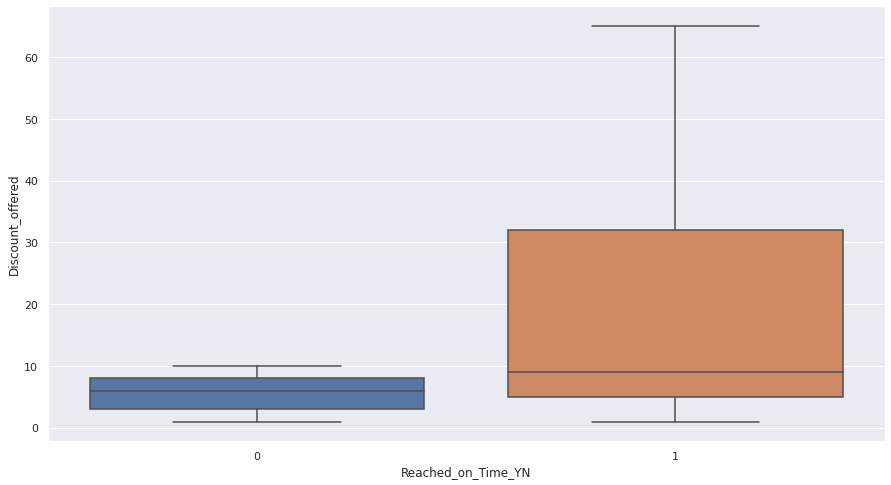

In [47]:
sns.boxplot(x = 'Reached_on_Time_YN', y = 'Discount_offered', data = df);

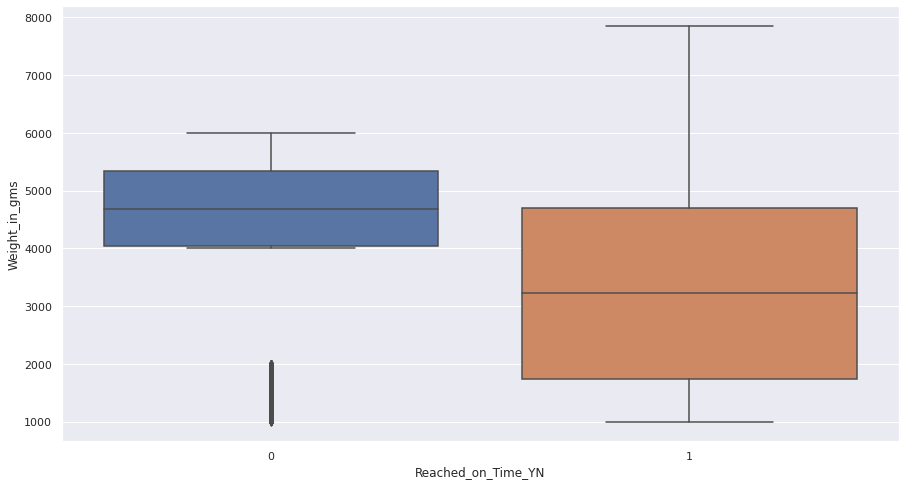

In [48]:
sns.boxplot(x = 'Reached_on_Time_YN', y = 'Weight_in_gms', data = df);